## Running LYNX

Conditional VGAE for integrated spatial trajectory reconstruction

In [1]:
import os
import gc
import sys
import time

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

import pyro
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from IPython.display import display

sns.set_context('paper')
# rcParams.update({'font.family': 'Liberation Sans'})
rcParams.update({'font.size': 12})
rcParams.update({'figure.dpi': 180})
rcParams.update({'savefig.dpi': 300})

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
sys.path.append('..')
sys.path.append('../models/')
sys.path.append('../util')

import IO, plot, utils, trajectory
import vgae, configs, dataset
from importlib import reload

In [4]:
%load_ext autoreload
%autoreload 2

Evaluation utils:

In [5]:
from scipy.special import comb

def plot_factor_corr(z):
    z_corr = np.corrcoef(z.T)
    z_score = np.abs(np.tril(z_corr, k=-1)).sum() / comb(z_corr.shape[0], 2)

    g = sns.clustermap(z_corr, cmap='RdBu_r')
    g.figure.suptitle(
        'q(z)\n Correlation score: {}'.format(np.round(z_score, 3)), 
        fontsize=30, y=1.05
    )
    plt.show()

# Plot overlapped 
def plot_overlap_latent(umap1, umap2, n_samples=5000):
    n_points = umap1.shape[0]
    indices = np.random.choice(np.arange(n_points), n_samples, replace=False)
    umap_df = pd.DataFrame(
        np.vstack([umap1[indices], umap2[indices]]),
        columns=['UMAP1', 'UMAP2']
    )
    umap_df['label'] = ['Prior']*n_samples + ['Posterior']*n_samples
    sns.kdeplot(
        data=umap_df, x='UMAP1', y='UMAP2', hue='label',
        levels=5, alpha=.5, fill=True
    )
    plt.title('Prior vs. Posterior manifolds')
    plt.show()

### Single-sample

In [6]:
# Load paired Xenium & DESI
xenium_path = '../data/real/'
desi_path = '../data/real/'
sample_id = 'NIH_F5'

adata_xenium = sc.read_h5ad(os.path.join(xenium_path, 'cell_feature_matrix.h5'))
adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id+'.h5'))
cell_types = pd.read_csv(os.path.join(xenium_path, 'cell_type.csv'), index_col=0)
adata_xenium = adata_xenium[cell_types.index]
adata_xenium.obs['cell_type'] = cell_types.cell_type
adata_xenium, adata_desi = IO.filter_cells(adata_xenium, adata_desi, by='map')

if 'cell_type' in adata_xenium.obs.keys():
    adata_xenium.obs['leiden'] = adata_xenium.obs.cell_type.factorize()[0]
else:
    adata_norm = adata_xenium.copy()
    sc.pp.normalize_total(adata_norm)
    sc.pp.log1p(adata_norm)

    sc.pp.pca(adata_norm)
    sc.pp.neighbors(adata_norm)
    sc.tl.leiden(adata_norm, random_state=42)

    adata_xenium.obs['leiden'] = adata_norm.obs['leiden'].copy()
    del adata_norm   


Load dataset:

In [7]:
# Dataset specs
n_subgraphs = 16
k = 100
r = 50

graph_data = dataset.HeteroDataset(
    adatas_ref=adata_xenium, 
    adatas_query=adata_desi,
    n_subgraphs=n_subgraphs, 
    k=k,
    r=r,
    is_weighted=True
)

train_data, val_data = random_split(graph_data, [0.7, 0.3])
train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

[2025-02-18 01:23:53] Update parameter r as 50
[2025-02-18 01:23:53] Update parameter is_weighted as True
[2025-02-18 01:23:53] Constructing graph partitions from data 1


[2025-02-18 01:24:02] Update parameter r as 50
[2025-02-18 01:24:02] Update parameter is_weighted as True
[2025-02-18 01:24:02] Constructing hetero-graph partitions from paired data 1


Configure model:

In [26]:
# Model parameters
n_hidden = 32
n_latent = 6

# Training parameters
n_epochs = 500
lr = 1e-3
patience = 10

# Training & Inference
train_configs = configs.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience, 
    device=torch.device('cuda'),
    anneal=True,
    verbose=True,
    #scheduler step and gamma applies gamma every step
    step_size=100,
    gamma=0.1
)

model_configs = configs.set_model_configs(
    c_in=adata_xenium.shape[1],   # ref-dim 
    c_aux=adata_desi.shape[1],  # query-dim
    c_hidden=n_hidden, 
    c_latent=n_latent,
    act=nn.LeakyReLU(),
    ref=graph_data.ref, 
    query=graph_data.query,
    k_hop=1,
    num_heads=1,
    num_clusters=graph_data.num_clusters,
    verbose=True
) 

[2025-02-18 03:08:21] Training config	anneal: True
[2025-02-18 03:08:21] Training config	betas: (0.95, 0.999)
[2025-02-18 03:08:21] Training config	device: cuda
[2025-02-18 03:08:21] Training config	gamma: 0.1
[2025-02-18 03:08:21] Training config	lr: 0.001
[2025-02-18 03:08:21] Training config	n_epochs: 500
[2025-02-18 03:08:21] Training config	patience: 10
[2025-02-18 03:08:21] Training config	step_size: 100
[2025-02-18 03:08:21] Training config	warmup_epochs: 50
[2025-02-18 03:08:21] Training config	weight_decay: 0.001
[2025-02-18 03:08:21] Model config	act: LeakyReLU(negative_slope=0.01)
[2025-02-18 03:08:21] Model config	batch_size: 1
[2025-02-18 03:08:21] Model config	beta: 1.0
[2025-02-18 03:08:21] Model config	c_aux: 615
[2025-02-18 03:08:21] Model config	c_hidden: 32
[2025-02-18 03:08:21] Model config	c_in: 377
[2025-02-18 03:08:21] Model config	c_latent: 6
[2025-02-18 03:08:21] Model config	dropout: 0.5
[2025-02-18 03:08:21] Model config	k_hop: 1
[2025-02-18 03:08:21] Model c

Epoch 138 train -ELBO: 195.396; val -ELBO: 196.202; val R2: 0.826; val corr: 0.418; pz corr: 0.453:  28%|██▊       | 139/500 [02:08<05:33,  1.08it/s]


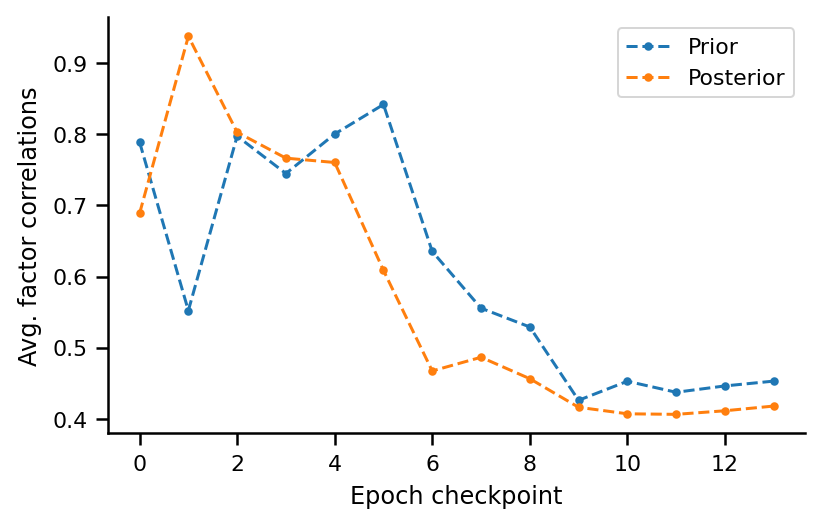

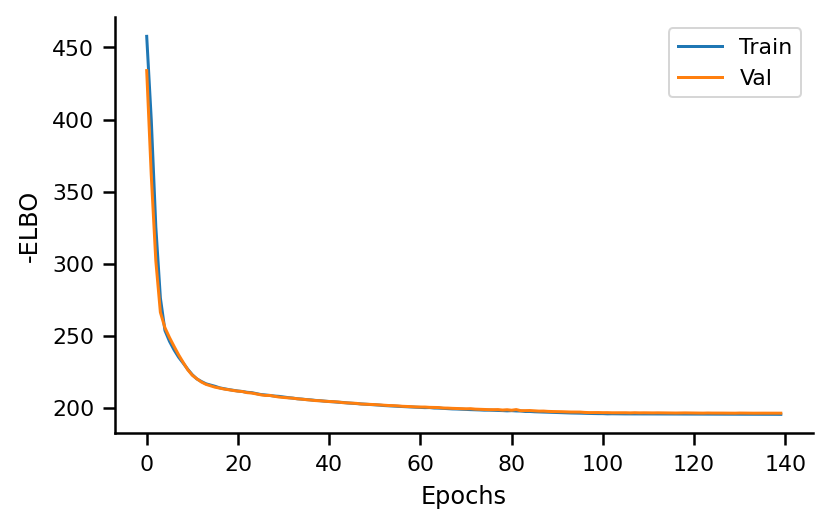

[2025-02-18 03:10:31] Update parameter r as 50
[2025-02-18 03:10:31] Update parameter is_weighted as True
[2025-02-18 03:10:31] Constructing graph partitions from data 1
[2025-02-18 03:10:40] Update parameter r as 50
[2025-02-18 03:10:40] Update parameter is_weighted as True
[2025-02-18 03:10:40] Update parameter ref as Xenium
[2025-02-18 03:10:40] Update parameter ref_proj_key as desi_map
[2025-02-18 03:10:40] Update parameter query as DESI
[2025-02-18 03:10:40] Update parameter query_proj_key as xenium_map
[2025-02-18 03:10:40] Constructing hetero-graph partitions from paired data 1


In [27]:
pyro.clear_param_store()
torch.cuda.empty_cache()

reload(vgae)

model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
model.fit(train_configs, train_dl=train_dl, val_dl=val_dl, DEBUG=True)

res = model.evaluate(
    adata_xenium, adata_desi,
    graph_data=graph_data,
    device=torch.device('cpu')
)

adata_xenium.obsm['X_z'] = res.qzx
adata_desi.obsm['X_z'] = res.qzu


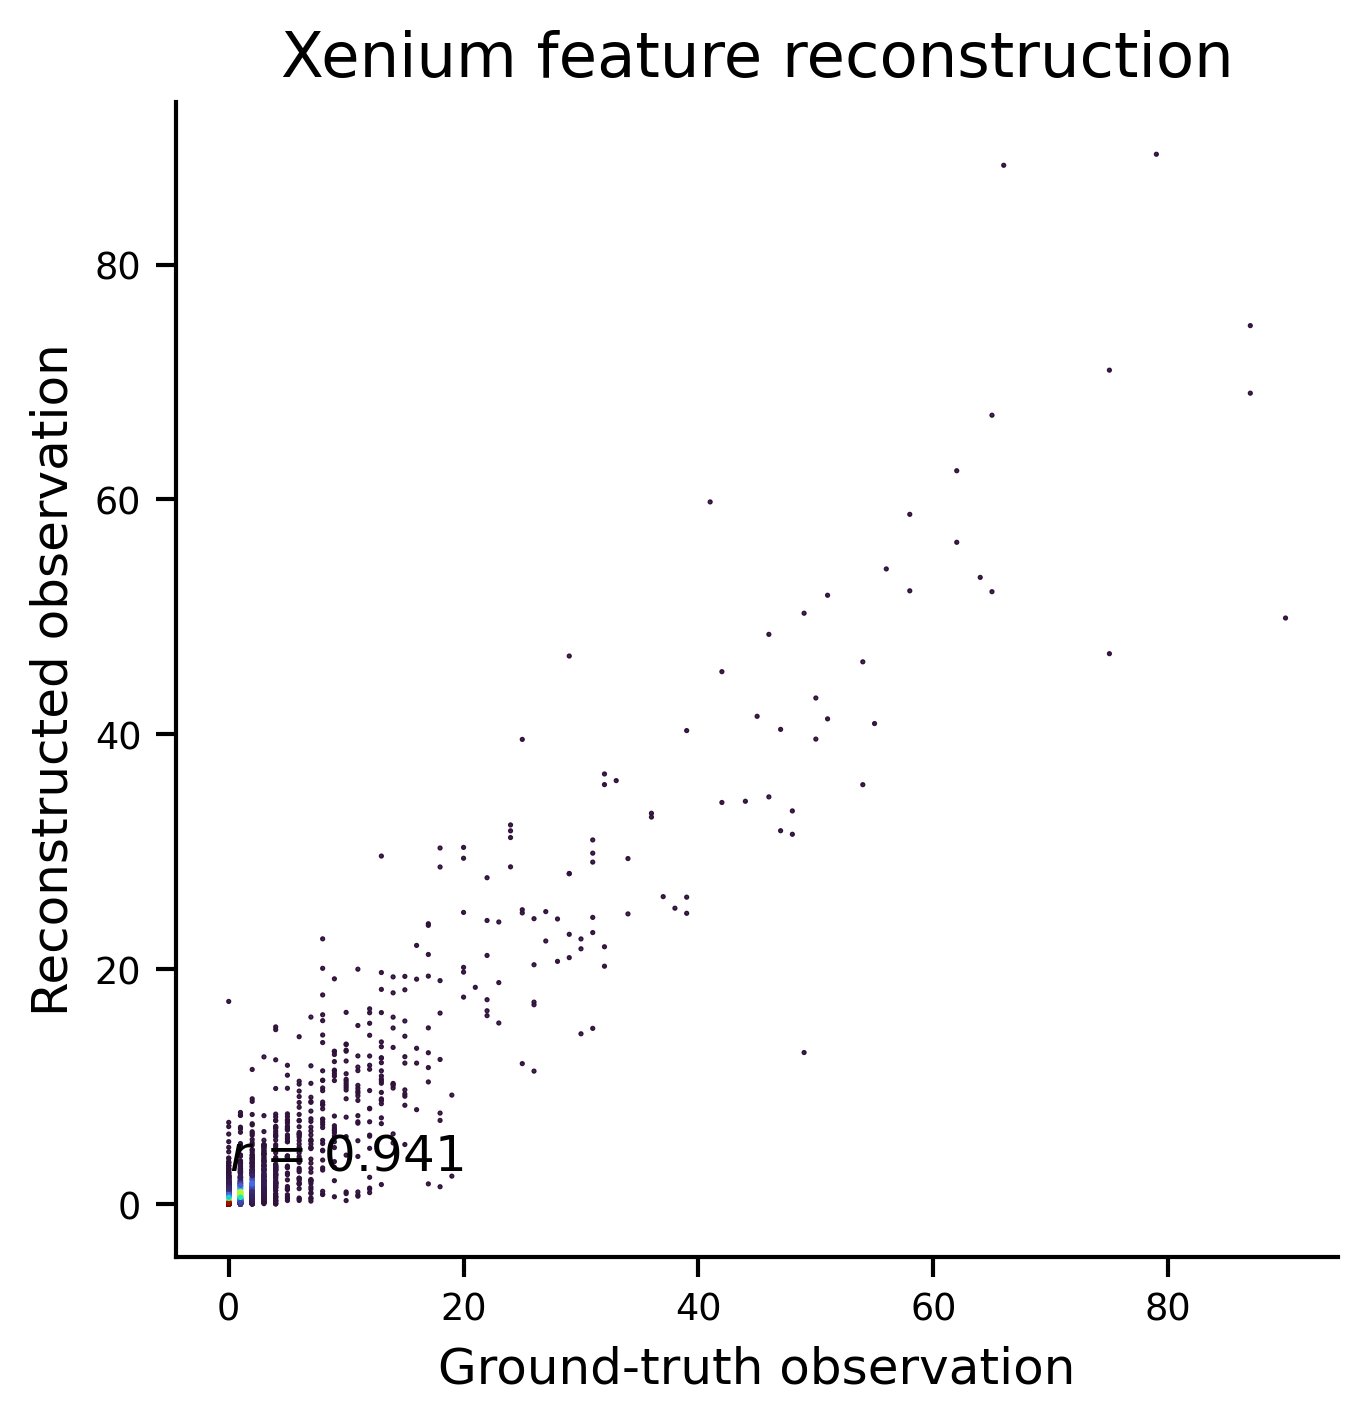

4015

In [28]:
# (1). Reconstruction
rand_indices = np.random.choice(
    np.arange(adata_xenium.shape[0]*adata_xenium.shape[1]), 10000, replace=False
)
plot.disp_kde_scatter(
    adata_xenium.X.A.flatten()[rand_indices],
    res.px.flatten()[rand_indices],
    xlabel=r"Ground-truth observation",
    ylabel=r"Reconstructed observation",
    title='Xenium feature reconstruction'
)
del rand_indices
gc.collect()

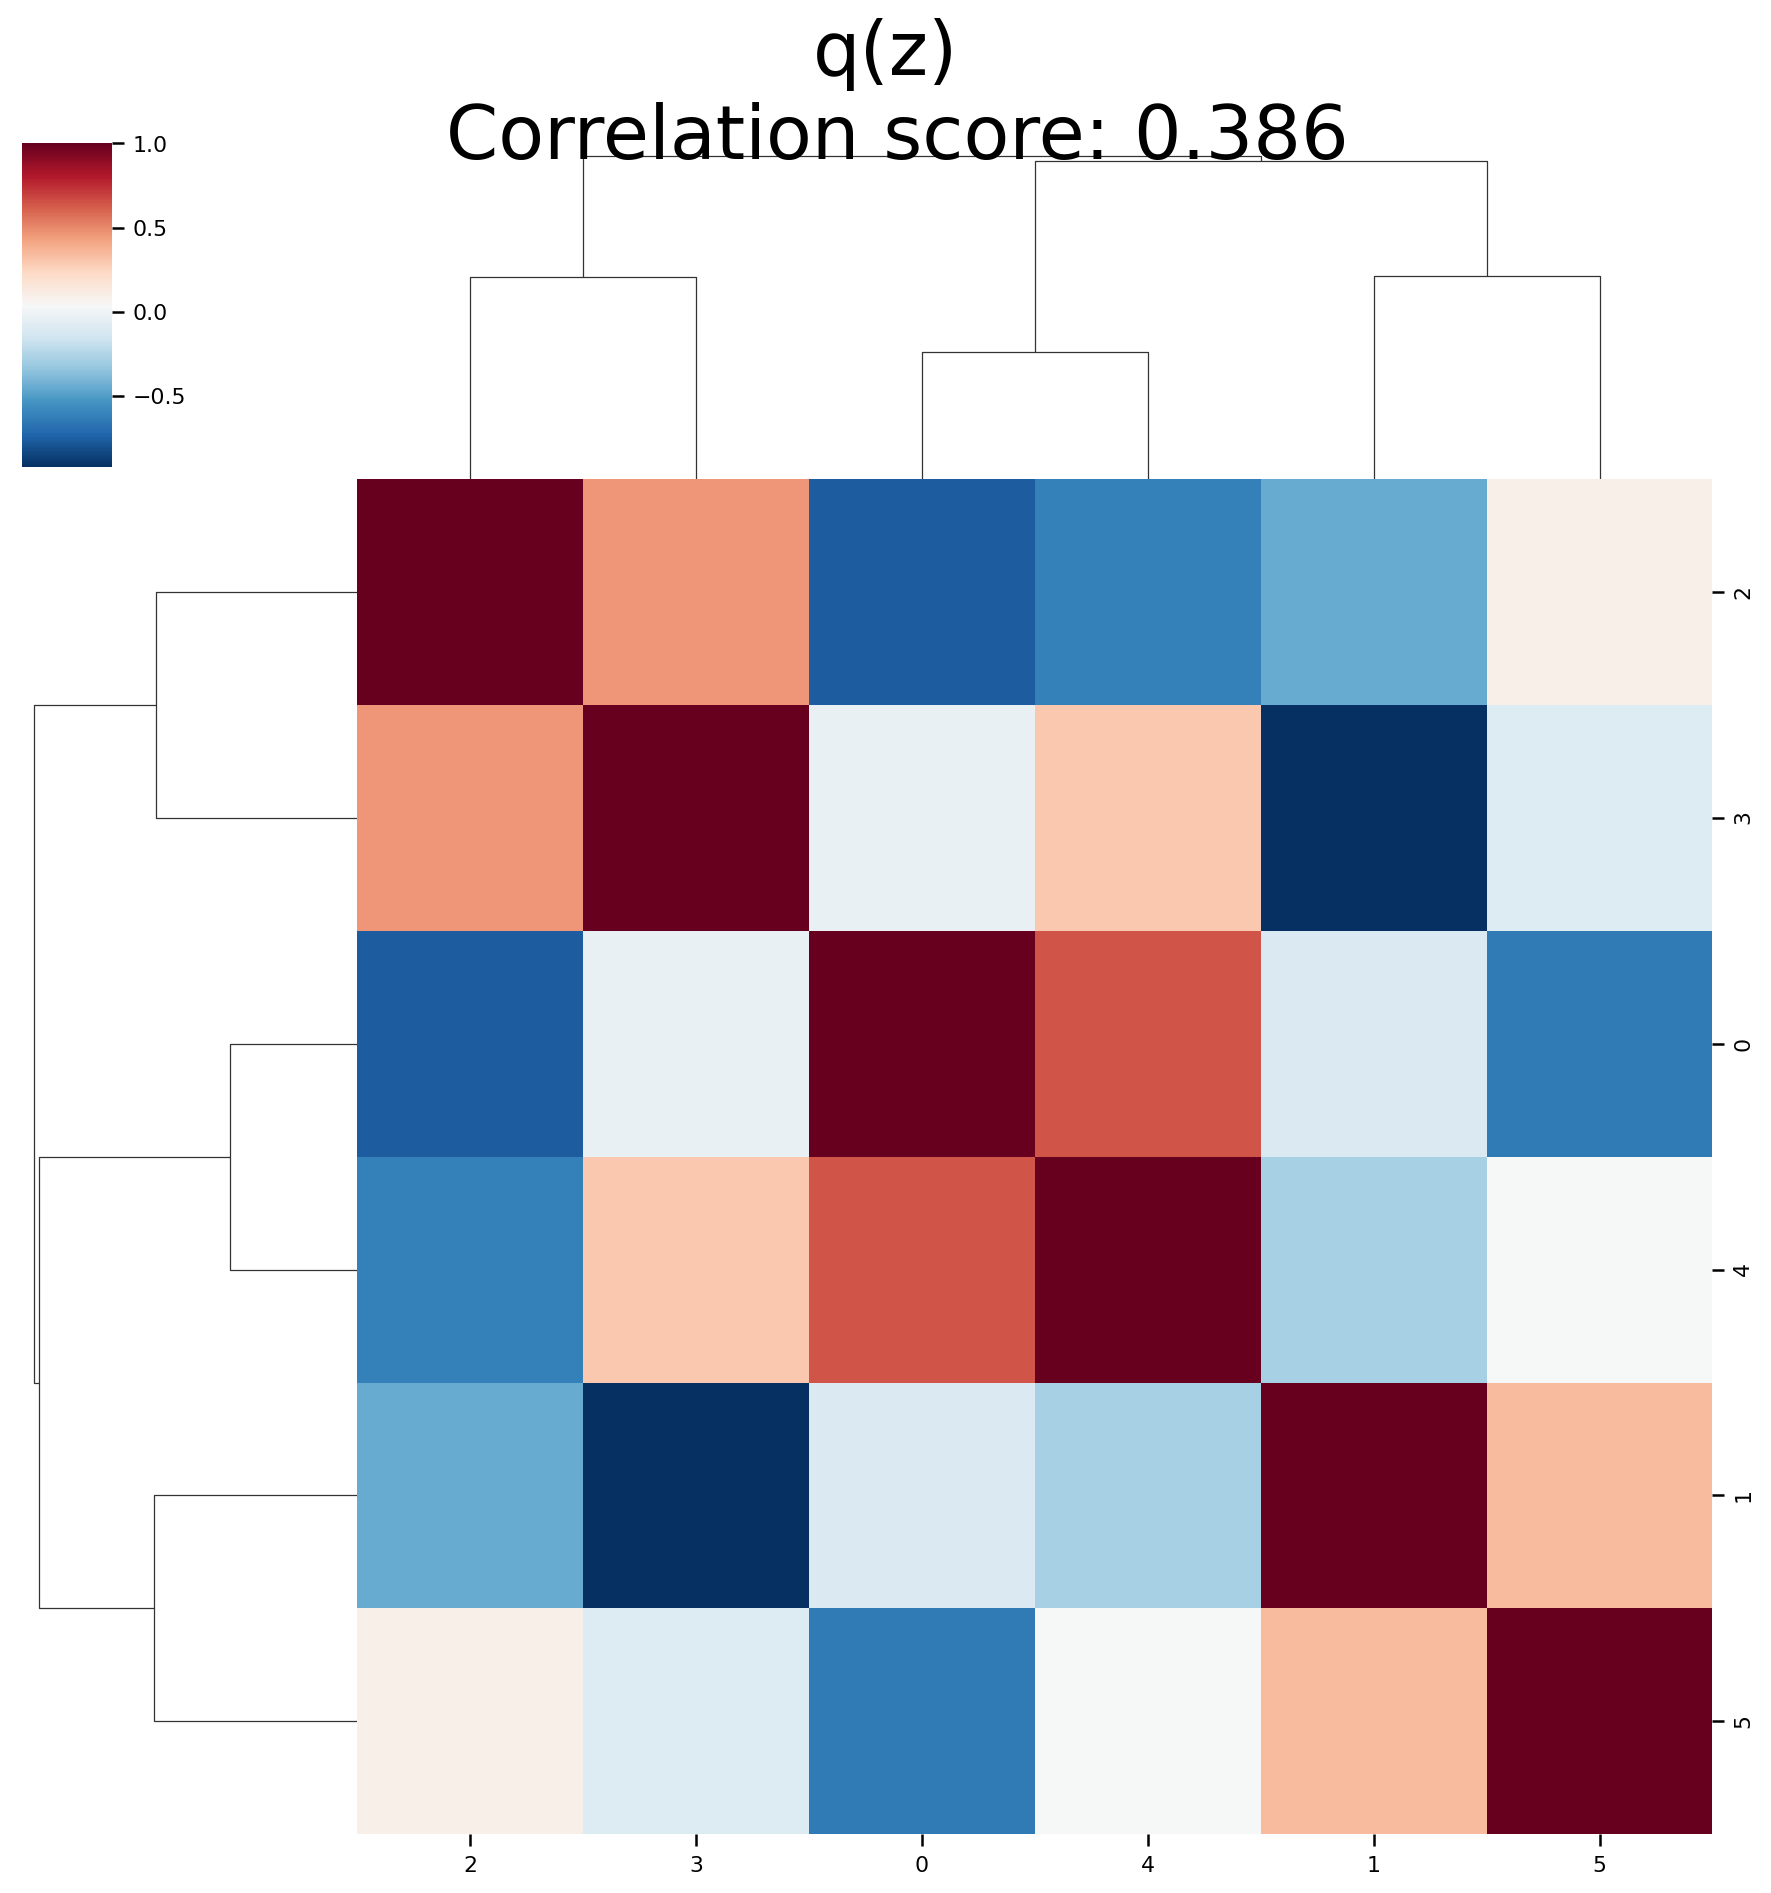

In [29]:
# (2). Latent disentanglement
plot_factor_corr(res.qzu)

# factor_labels = ['z'+str(i) for i in range(n_latent)]
# adata_desi.obs[factor_labels] = adata_desi.obsm['X_z'].copy()

# sc.pp.neighbors(adata_desi, n_neighbors=k, use_rep='X_z')
# sc.tl.umap(adata_desi)
# sc.pl.umap(adata_desi, color=factor_labels, cmap='turbo', ncols=3)

# sq.pl.spatial_scatter(
#     adata_desi, color=factor_labels, cmap='turbo',
#     ncols=3, size=1, img=False
# )
# adata_desi.obs.drop(factor_labels, axis=1, inplace=True)

# del factor_labels

inferring a principal curve --> parameters used 
    20 principal points, mu = 0.05, lambda = 0.1
(2, 6)
(20, 6)
    finished (0:00:12) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.
inferring a principal curve --> parameters used 
    20 principal points, mu = 0.05, lambda = 0.1
(2, 6)
(20, 6)
    finished (0:00:02) --> added 
    .uns['epg'] dictionnary containing inferred elastic curve generated from elpigraph.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'], coordinates of principal points in representation space.


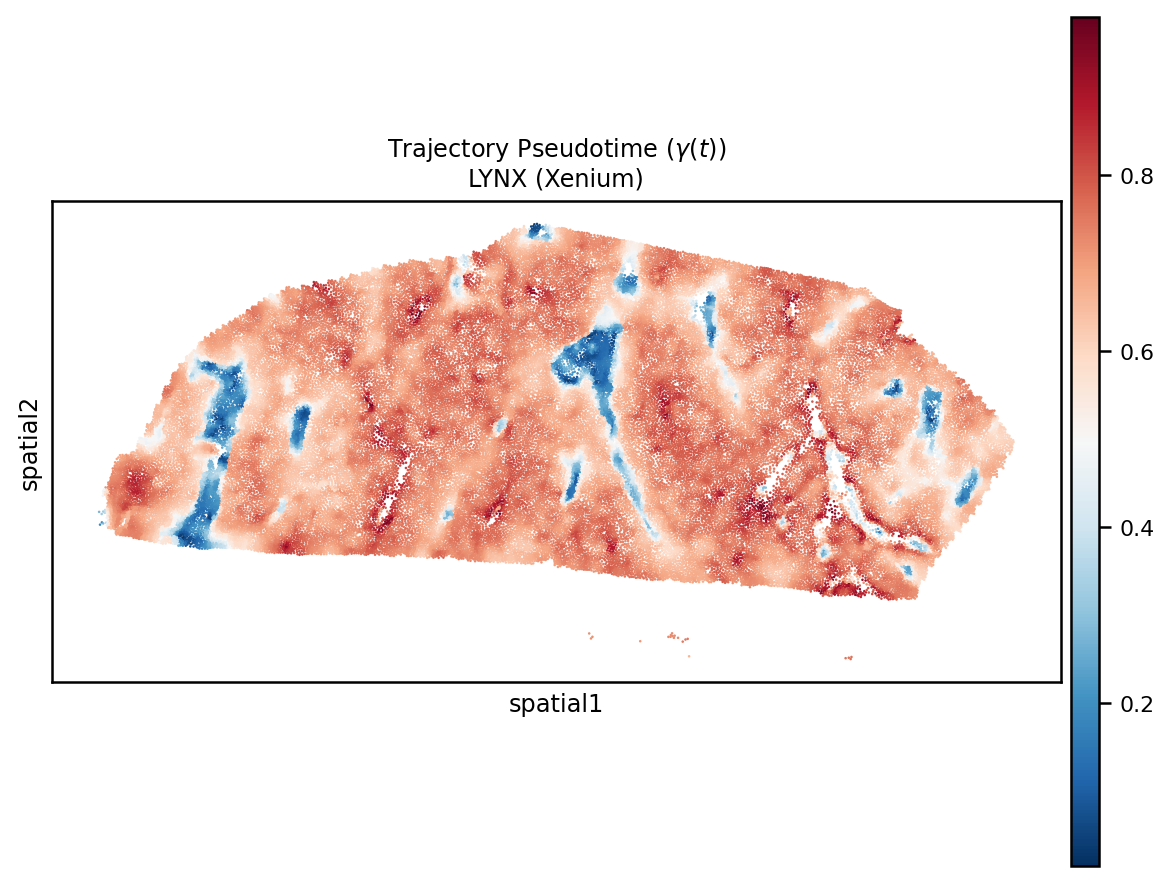

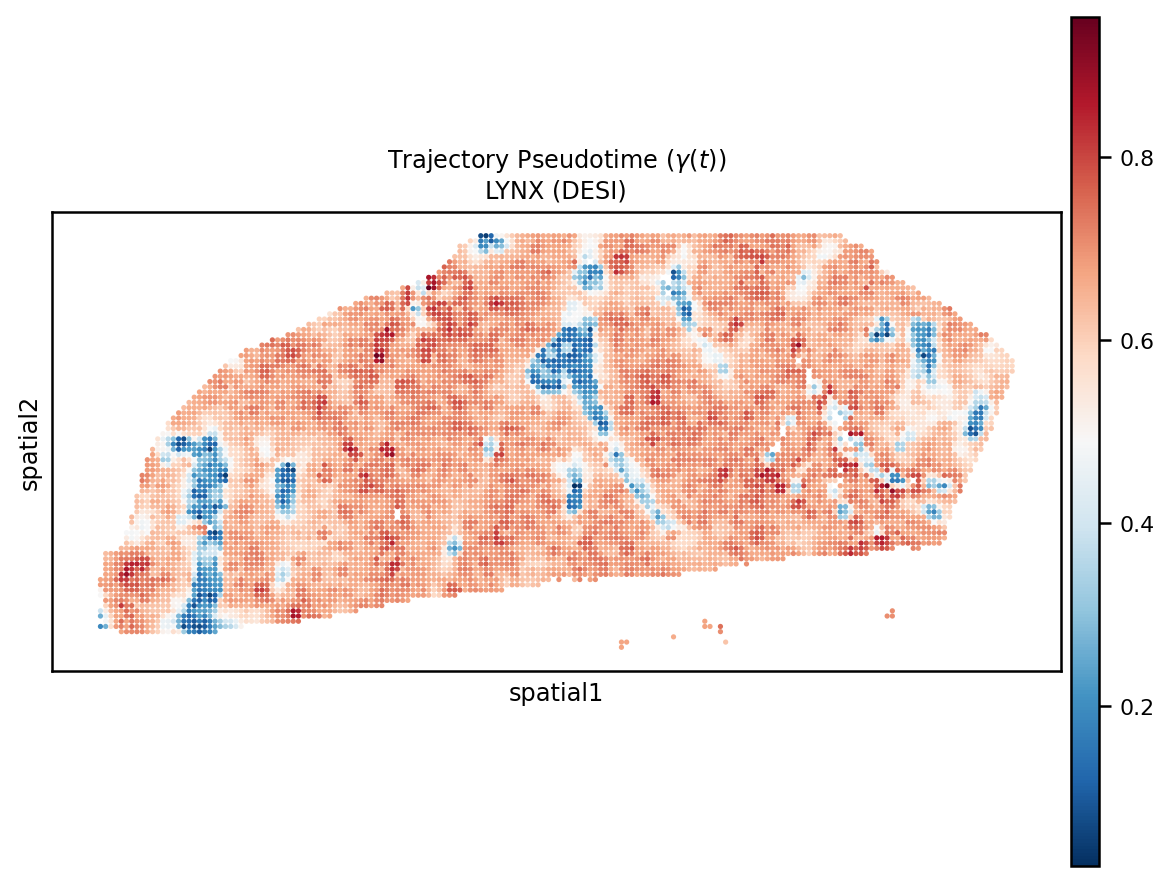

In [30]:
# (3). Trajectory inference

# High-dim gradients (x)
trajectory.compute_trajectory(
    adata_xenium, 
    use_rep='X_z',
    root_marker='DPT'
)

sq.pl.spatial_scatter(
    adata_xenium, color='t', 
    cmap='RdBu_r', size=20, img=False,
    title=r'Trajectory Pseudotime ($\gamma(t)$)'+'\nLYNX (Xenium)'
)

# Low-dim gradients (u)
adata_desi.obsm['X_z'] = res.qzu
trajectory.compute_trajectory(
    adata_desi, 
    use_rep='X_z',
    root_marker='Taurine '
)

sq.pl.spatial_scatter(
    adata_desi, color='t', 
    cmap='RdBu_r', size=1, img=False,
    title=r'Trajectory Pseudotime ($\gamma(t)$)'+'\nLYNX (DESI)'
)


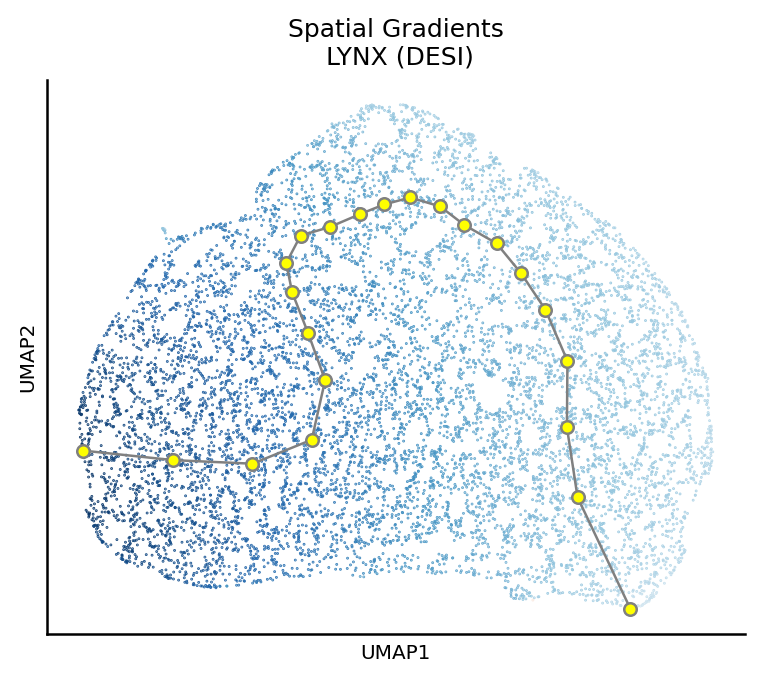

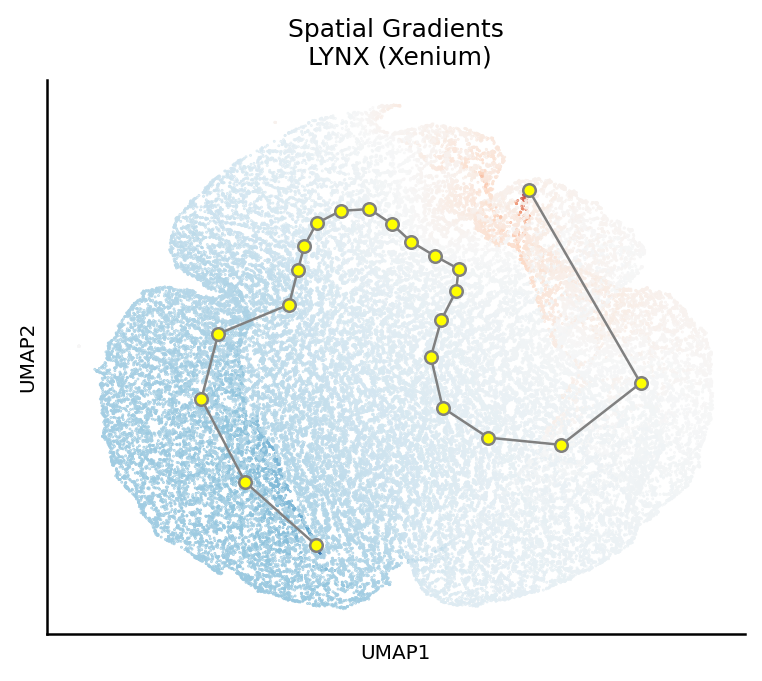

In [16]:
plot.disp_trajectory(
    adata_desi, cmap='RdBu_r',
    title='Spatial Gradients\n LYNX (DESI)'
)

plot.disp_trajectory(
    adata_xenium, cmap='RdBu_r',
    title='Spatial Gradients\n LYNX (Xenium)'
)

In [ ]:
# np.save('../results/lynx_{0}_attn.npy'.format(n_latent), adata.obsm['X_z'])

### All-samples

In [ ]:
xenium_path = '../data/xenium/'
desi_path = '../data/desi/'
sample_ids = sorted([
    sample_id for sample_id in os.listdir(xenium_path)
    if os.path.isdir(os.path.join(xenium_path, sample_id))
])

Configure model:

In [ ]:
# Dataset specs
n_subgraphs = 16
k = 100
r = 50
# dist_metric = 'euclidean'

# Model parameters
n_hidden = 32
n_latent = 6

# Training parameters
n_epochs = 500
lr = 1e-3
patience = 50

# Training & Inference
train_configs = configs.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience, 
    device=torch.device('cuda'),
    anneal=True,
    verbose=True
)

Full model training:

In [ ]:
# Iterate through individual samples
latents_ref = []
latents_query = []

for sample_id in sample_ids:
    print('Training on {}...'.format(sample_id))

    # ---------------
    # Loading data
    # ---------------
    
    adata_xenium = IO.load_xenium(os.path.join(xenium_path, sample_id), load_img=True)
    adata_desi = sc.read_h5ad(os.path.join(desi_path, sample_id+'.h5'))
    adata_xenium, adata_desi = IO.filter_cells(adata_xenium, adata_desi, by='map')

    if 'cell_type' in adata_xenium.obs.keys():
        adata_xenium.obs['leiden'] = adata_xenium.obs.cell_type.factorize()[0]
    else:
        adata_norm = adata_xenium.copy()
        sc.pp.normalize_total(adata_norm)
        sc.pp.log1p(adata_norm)
    
        sc.pp.pca(adata_norm)
        sc.pp.neighbors(adata_norm)
        sc.tl.leiden(adata_norm, random_state=42)
    
        adata_xenium.obs['leiden'] = adata_norm.obs['leiden'].copy()
        del adata_norm   


    graph_data = dataset.HeteroDataset(
        adatas_ref=adata_xenium, 
        adatas_query=adata_desi,
        n_subgraphs=n_subgraphs, 
        k=k,
        r=r,
        is_weighted=True
    )

    train_data, val_data = random_split(graph_data, [0.7, 0.3])
    train_dl, val_dl = DataLoader(train_data, shuffle=True), DataLoader(val_data)

    model_configs = configs.set_model_configs(
        c_in=adata_xenium.shape[1],   # ref-dim 
        c_aux=adata_desi.shape[1],  # query-dim
        c_hidden=n_hidden, 
        c_latent=n_latent,
        act=nn.SiLU(),
        ref=graph_data.ref, 
        query=graph_data.query,
        k_hop=1,
        num_heads=1,
        num_clusters=graph_data.num_clusters,
        verbose=True
    ) 

    # -----------------------
    # Training & Inference
    # -----------------------
    model = vgae.HeteroVGAE(model_configs, device=torch.device('cuda'))
    model.fit(train_configs, train_dl=train_dl, val_dl=val_dl)

    res = model.evaluate(
        adata_xenium, adata_desi,
        graph_data=graph_data,
        device=torch.device('cpu')
    )

    adata_xenium.obsm['X_z'] = res.qzx
    adata_desi.obsm['X_z'] = res.qzu

    latents_ref.append(res.qzx)
    latents_query.append(res.qzu)

    del model
    gc.collect()
    torch.cuda.empty_cache()
    pyro.clear_param_store()

    
    # ----------------
    # Visualization
    # ----------------
    
    # Factor disentanglement
    plot_factor_corr(res.qzu)

    # Trajectory inference
    try:
        trajectory.compute_trajectory(
            adata_xenium, 
            use_rep='X_z',
            root_marker='DPT',
        )

        trajectory.compute_trajectory(
            adata_desi, 
            use_rep='X_z',
            root_marker='Taurine '
        )

        # plot.disp_trajectory(
        #     adata_desi, 
        #     cmap='RdBu',
        #     title='Spatial Gradients\n LYNX (DESI)'
        # )

        # disp_spatial_latents(adata_xenium)

        sq.pl.spatial_scatter(
            adata_xenium, color='t', 
            cmap='RdBu', size=20, img=False,
            title=r'Trajectory Pseudotime ($\gamma(t)$)'+'\nLYNX (Xenium)'
        )

        sq.pl.spatial_scatter(
            adata_desi, color='t', 
            cmap='RdBu', size=1, img=False,
            title=r'Trajectory Pseudotime ($\gamma(t)$)'+'\nLYNX (DESI)'
        )

        sc.pp.normalize_total(adata_xenium)
        sc.pp.log1p(adata_xenium)
        utils.get_zonation_features(    
            adata_xenium, adata_desi,
            n_zones=5, sample_id=sample_id,
            show=True
        )

        plt.show()
        time.sleep(5)
        
        # Saving results
        np.save('../results/lynx_hetero_xenium_{0}_{1}.npy'.format(n_latent, sample_id), adata_xenium.obsm['X_z'])
        np.save('../results/lynx_hetero_desi_{0}_{1}.npy'.format(n_latent, sample_id), adata_desi.obsm['X_z'])
                
    except ValueError:
        continue

    gc.collect()
    
    print('=============\n\n')

---